In this notebook we recreate the plots that were presented in 'Cosmological perturbations with ultralight vector dark matter fields: numerical implementation in CLASS'.

In [4]:
#import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import math

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

#%matplotlib widget

### LCDM

In [5]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [6]:
# Common settings and LCDM
colors = plt.cm.jet(np.linspace(0., 0.48, 4))
colors = ['#BC7AE0', '#3C536D', '#DAC746', '#3390D7', '#DC4D57']
masses= [1.e-25, 1.e-24, 1.e-23, 1.e-22, 1.e-19] # eV
masses_Mpc = [mass*1.56373846613383*1.e29 for mass in masses]# Mpc^-1

lcdm = Class()
lcdm_settings = {'omega_b':omega_b,'Omega_cdm' : omega_cdm/h_planck**2,
                 'h' : h_planck,
                 'A_s' : As,
                 'n_s':ns,'tau_reio':tau_reio,
                 'YHe': 'BBN','output':'tCl mPk','gauge':'synchronous',
                 'P_k_max_h/Mpc':10.0, 'format': 'camb', 'ic' : 'ad','P_k_ini type' : 'analytic_Pk',
                 'z_pk': '0,10,100', 'Omega_k' : 0., 'N_ncdm' : 0}
lcdm.set(lcdm_settings)

lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
background_lcdm = lcdm.get_background()

frac = 1-1.e-6

common_settings  = {
            'h' : h_planck,    
            'omega_b' : omega_b,
            'Omega_cdm' : omega_cdm*(1-frac)/h_planck**2,
            'Omega_dcdmdr' : 0.0,
            'N_ncdm' : 0,
            'Omega_k' : 0.,
            'Omega_fld' : 0.,
            'Omega_vf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_vf' : 'yes',
            'vf_tuning_index' : 3,
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl mPk',
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'P_k_ini type' : 'analytic_Pk',
            'P_k_max_h/Mpc':10.0,
            'A_s' : As,
            'n_s' : ns,
            'format': 'camb',
            'vector_background_mode' : 'bianchi',
            }

In [7]:
# --- key LCDM background scales ---
bg_z   = background_lcdm['z']
bg_a   = 1./(1. + bg_z)
bg_H   = background_lcdm['H [1/Mpc]']
bg_tau = background_lcdm['conf. time [Mpc]']

rho_m  = background_lcdm['(.)rho_cdm'] + background_lcdm['(.)rho_b']
rho_r  = background_lcdm['(.)rho_g']+background_lcdm['(.)rho_ur']

H0     = float(interp1d(bg_z,  bg_H  )(0.0))
tau_0  = float(interp1d(bg_z,  bg_tau)(0.0))
a_eq   = float(interp1d(rho_m/rho_r, bg_a)(1.))
tau_eq = float(interp1d(bg_a, bg_tau)(a_eq))

print(f'H0     = {H0:.6e} Mpc^-1')
print(f'tau_0  = {tau_0:.6e} Mpc')
print(f'tau_eq = {tau_eq:.6e} Mpc')
print(f'a_eq   = {a_eq:.6e}')

H0     = 2.230877e-04 Mpc^-1
tau_0  = 1.417999e+04 Mpc
tau_eq = 1.125415e+02 Mpc
a_eq   = 2.930624e-04


In [8]:
cosmo0 = {}
for m in range(len(masses)):

    cosmo0[m] = Class()
    cosmo0[m].set(common_settings)
    cosmo0[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%masses[m]})
    cosmo0[m].set({'vector_background_mode' : 'bianchi'})
    cosmo0[m].set({'gamma_Ak': 0})
    cosmo0[m].compute()

    print(masses[m])

1e-25
1e-24
1e-23
1e-22
1e-19


# Background Evolution

Here we present the evolution of the background quantities. Firstly, let's plot the matter density in terms of the scale factor.

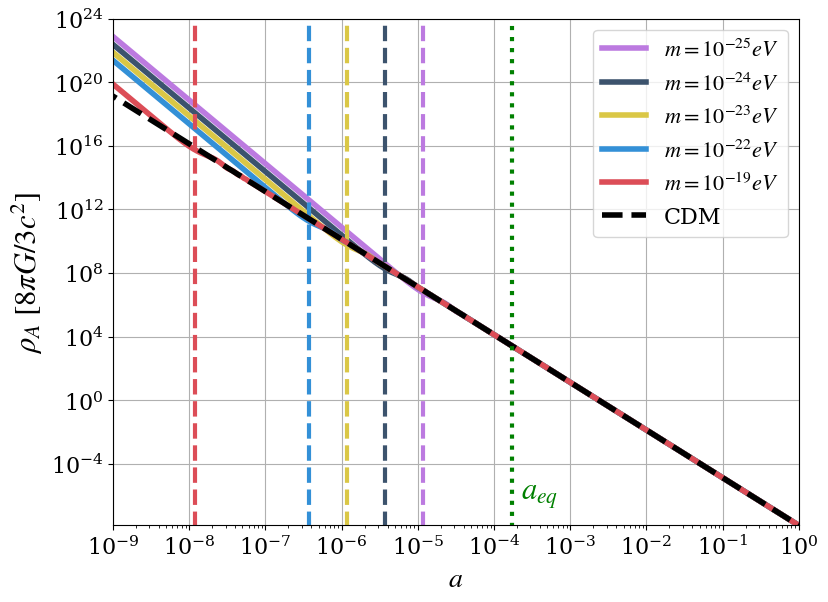

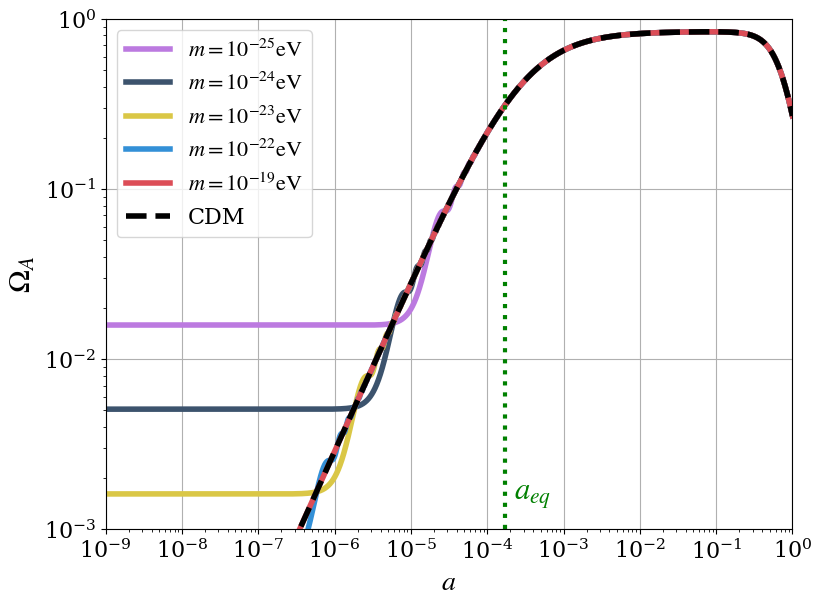

In [9]:
#### Background ####
for m in range(len(masses)):
    background = cosmo0[m].get_background()
    background_z = background['z']
    background_a = 1/(1+background_z)
    rho_vf = np.exp(background['Omega_vf']) * background['H [1/Mpc]'] * background['H [1/Mpc]']
    background_m_over_H = masses[m] * 1.56 * 10**(29)/background['H [1/Mpc]'] 
    z_at_m_over_H = interp1d(background_m_over_H, background_z)
    a_at_m_over_H = interp1d(background_m_over_H, background_a)

    theta = background['theta_vf']

    plt.figure(3,figsize=(8, 6))
    plt.loglog(background_a, rho_vf, color=colors[m], label=r'$m=10^{%s}eV$'% str(masses[m])[-3:], lw=4)
    plt.vlines(1/(1+z_at_m_over_H(1)), 1.e-8, 1.e24, colors=colors[m], linestyles='dashed', lw=3)
    plt.ylabel(r'$\rho_A \,\,\left[8\pi G/3 c^2\right]$', size=22)
    plt.xlabel(r'$a$', size=20)
    if masses[m] == masses[-1]:
        background_lcdm = lcdm.get_background()
        background_a_lcdm = 1/(1+background_lcdm['z'])
        plt.loglog(background_a_lcdm, background_lcdm['(.)rho_cdm'], 'k--', label=r'CDM', lw=4)
        plt.grid()
        plt.legend(fontsize=16)
        plt.tight_layout()
        rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
        mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
        a_equality = interp1d(mat_abundance/rad_abundance, background_a)
        plt.vlines(a_equality(1.),  1.e-8, 1.e25, colors='g', linestyles='dotted', lw=3)
        plt.xlim(1.e-9,background_a_lcdm[-1])
        plt.ylim(min(rho_vf),1.e24)
        plt.tick_params(axis='both',labelsize=16)
        plt.text(1.3*a_equality(1.), 6.e-7, r'$a_{eq}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
        plt.savefig('../../Figures/rho_A.pdf')
    rad_abundance = background['(.)rho_g']/background['(.)rho_crit']
    mat_abundance = np.exp(background['Omega_vf'])+background['(.)rho_b']/background['(.)rho_crit']
    a_equality = interp1d(mat_abundance/rad_abundance, background_a)

    plt.figure(4,figsize=(8, 6))
    plt.loglog(background_a, rho_vf/(background['H [1/Mpc]'])**2, color=colors[m], label=r'$m=10^{%s}\rm{eV}$'% str(masses[m])[-3:], lw=4)
    plt.ylabel(r'$\Omega_A$', size=22, family= 'STIXGeneral')
    plt.xlabel(r'$a$', size=20)
    if masses[m] == masses[-1]:
        plt.loglog(background_a_lcdm, background_lcdm['(.)rho_cdm']/(background_lcdm['H [1/Mpc]'])**2, 'k--', label=r'CDM', lw=4)
        plt.grid()
        plt.legend(fontsize=16)
        plt.tight_layout()
        rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
        mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
        a_equality = interp1d(mat_abundance/rad_abundance, background_a)
        plt.ylim((1.e-3 , 1.))
        plt.xlim(1.e-9,background_a[-1])
        plt.vlines(a_equality(1.),  1.e-3, 1.e0, colors='g', linestyles='dotted', lw=3)
        plt.text(1.3*a_equality(1.), 1.5*1.e-3, r'$a_{eq}$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.tick_params(axis='both',labelsize=16)
plt.savefig('../../Figures/Omega_A.pdf')
plt.show()

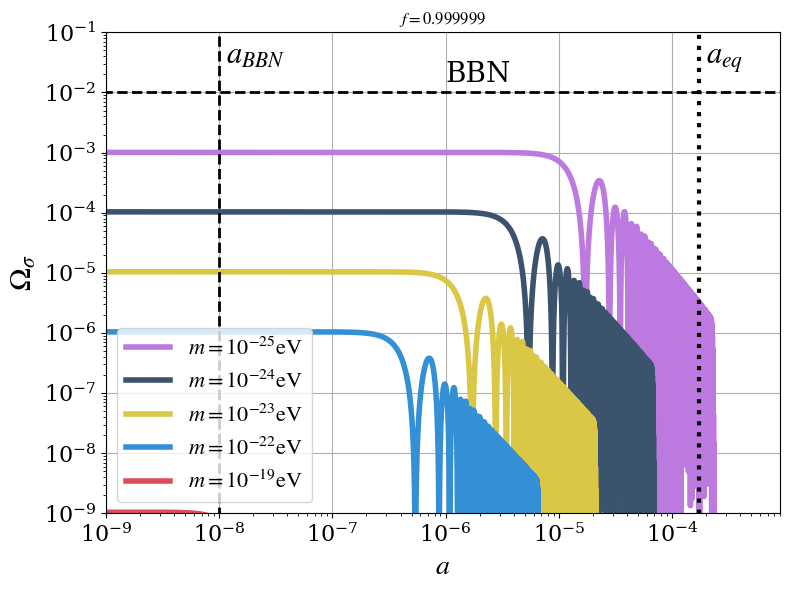

In [10]:
plt.figure(figsize=(8, 6))
for m in range(len(masses)):
    background = cosmo0[m].get_background()
    background_z = background['z']
    background_a = 1/(1+background_z)
    background_m_over_H = masses_Mpc[m]/background['H [1/Mpc]'] 
    z_at_m_over_H = interp1d(background_m_over_H, background_z)
    a_at_m_over_H = interp1d(background_m_over_H, background_a)
    rho_vf = np.exp(background['Omega_vf']) * background['H [1/Mpc]'] * background['H [1/Mpc]']

    background_lcdm = lcdm.get_background()

    rad_abundance = background['(.)rho_g']/background['(.)rho_crit']
    mat_abundance = np.exp(background['Omega_vf'])+background['(.)rho_b']/background['(.)rho_crit']
    a_equality = interp1d(mat_abundance/rad_abundance, background_a)
    h = cosmo0[m].h()

    metric_shear_prime = background['sigma_A_prime [1/Mpc^2]']
    metric_shear = background['sigma_A [1/Mpc]']

    if m == 0:
        maxvline = max(rho_vf)
    shear_abundance = 3./2. * metric_shear*metric_shear/(6*background['H [1/Mpc]']*background['H [1/Mpc]']*background_a*background_a)  # \Omega_{\sigma}
    a_BBN = 10**(-8)
    a_ini_plot = 0
    plt.figure(1)
    plt.loglog(background_a[a_ini_plot:], shear_abundance[a_ini_plot:], color=colors[m], label=r'$m=10^{%s}\rm{eV}$'% str(masses[m])[-3:], lw=4)
    plt.ylabel(r'$\Omega_{\sigma}$', size=22)
    plt.xlabel(r'$a$', size=20)
    if masses[m] == masses[-1]:
        plt.hlines(10**(-2), background_a[a_ini_plot], background_a[-1], colors='k', linestyles='dashed', lw=2)
        plt.vlines(x=a_BBN, ymin=np.min(shear_abundance), ymax= 1.1*maxvline, colors='k', linestyles='dashed', lw=2)
        plt.vlines(x=a_equality(1.), ymin=np.min(shear_abundance), ymax= 1.1*maxvline, colors='k', linestyles='dotted', lw=3)
        plt.text(a_equality(1.)*1.15, 3*10**(-2), r'$a_{eq}$', {'color': 'black', 'fontsize': 22})
        plt.text(a_BBN*1.15, 3*10**(-2), r'$a_{BBN}$', {'color': 'black', 'fontsize': 22})
        plt.text(1.e-6, 1.5*10**(-2), 'BBN', {'color': 'black', 'fontsize': 20})
        plt.ylim(1.e-9,1.e-1)
        plt.xlim(1.e-9, 9.e-4)#,1.e-2)
        plt.title(r'$f = %s$' % frac)
        plt.grid()
        plt.legend(loc='lower left', fontsize=16)
        plt.tick_params(axis='both',labelsize=16)
        plt.tight_layout()
plt.savefig('../../Figures/Omega_sigma.pdf',format='pdf')
plt.savefig('../../Figures/Omega_sigma.png',format='png')

## Spin 1 - Spin 0

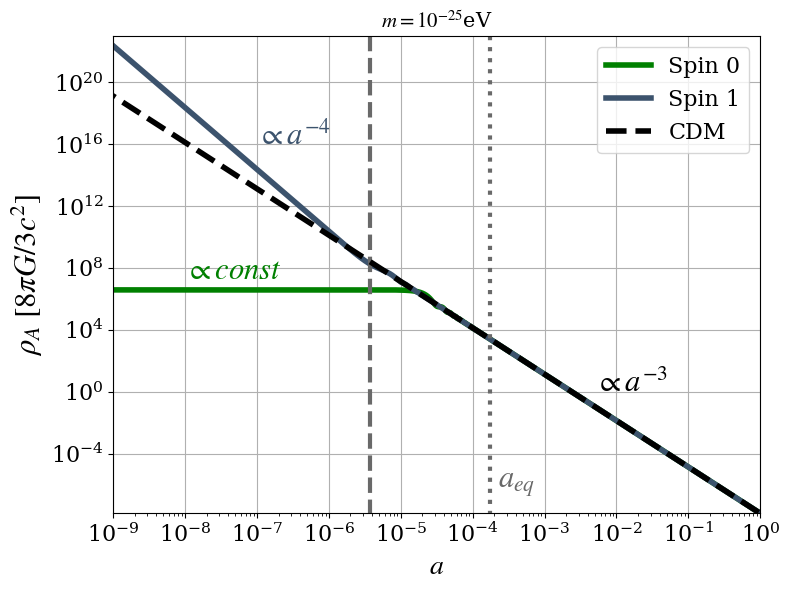

In [11]:
data_scf = np.loadtxt('../../SFDM_data/background_scf/rho_SFDM_m=-25')

a_scf = data_scf[:,0]  # first column
delta_scf = data_scf[:,1]  # second column

#### Background ####
m = 1
background = cosmo0[m].get_background()
background_lcdm = lcdm.get_background()
background_a_lcdm = 1/(1+background_lcdm['z'])
background_z = background['z']
background_a = 1/(1+background_z)
rho_vf = np.exp(background['Omega_vf']) * background['H [1/Mpc]'] * background['H [1/Mpc]']
background_m_over_H = masses[m] * 1.56 * 10**(29)/background['H [1/Mpc]'] 
z_at_m_over_H = interp1d(background_m_over_H, background_z)
a_at_m_over_H = interp1d(background_m_over_H, background_a)

rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
a_equality = interp1d(mat_abundance/rad_abundance, background_a)

rad_abundance = background['(.)rho_g']/background['(.)rho_crit']
mat_abundance = np.exp(background['Omega_vf'])+background['(.)rho_b']/background['(.)rho_crit']
a_equality = interp1d(mat_abundance/rad_abundance, background_a)

theta = background['theta_vf']

plt.figure(3,figsize=(8, 6))
plt.loglog(a_scf, delta_scf, color='g', label=r'Spin 0', lw=4)
plt.loglog(background_a, rho_vf, color=colors[m], label=r'Spin 1', lw=4)
plt.vlines(1/(1+z_at_m_over_H(1)), 1.e-8, 1.e24, colors='dimgrey', linestyles='dashed', lw=3)
plt.ylabel(r'$\rho_A \,\,\left[8\pi G/3 c^2\right]$', size=22)
plt.xlabel(r'$a$', size=20)
plt.loglog(background_a_lcdm, background_lcdm['(.)rho_cdm'], 'k--', label=r'CDM', lw=4)
plt.grid()
plt.legend(fontsize=16)
plt.title(r'$m = 10^{-25}$eV', fontsize=15)
plt.vlines(a_equality(1.),  1.e-8, 1.e25, colors='dimgrey', linestyles='dotted', lw=3)
plt.xlim(1.e-9,background_a_lcdm[-1])
plt.ylim(min(rho_vf),1.e23)
plt.tick_params(axis='both',labelsize=16)
plt.text(1.3*a_equality(1.), 6.e-7, r'$a_{eq}$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=22)
plt.text(1.e-7, 1.e16, r'$\propto a^{-4}$', fontdict={'color':colors[m], 'fontweight':'bold'}, size=22)
plt.text(1.e-8, 2.e7, r'$\propto const$', fontdict={'color':'g', 'fontweight':'bold'}, size=22)
plt.text(5.e-3, 1.e0, r'$\propto a^{-3}$', fontdict={'color':'k', 'fontweight':'bold'}, size=22)
plt.tight_layout()
plt.savefig('../../Figures/rho_COMPARISON.pdf')
plt.savefig('../../Figures/rho_COMPARISON.png')